In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
df = pd.read_csv('/content/WORK_bank_data_train.csv', sep=';')

print(df.shape)
display(df.head())

df.info()
print("\nПроцент пропусков по колонкам:")
print(df.isnull().mean().sort_values(ascending=False) * 100)


(985477, 22)


,ID,Age,Ind_Household,Age_group,District,Region,Lifetime,Income,Segment,Ind_deposit,...,Ind_salary,trans_6_month,trans_9_month,trans_12_month,amont_trans,amont_day_from,trans_3_month,Gender,Target1,Target2
0,1200000001,51.0,No,middle,02,Midlands,3.0,53,Platinum,No,...,No,2026.27,2964.23,4140.91,3,21,910.02,F,No,No
1,1200000002,47.0,No,middle,34,Midlands,2.0,51,Gold,No,...,No,2033.14,2969.30,4202.63,5,14,977.80,U,No,No
2,1200000003,45.0,No,middle,17,North,6.0,50,Silver,No,...,No,2085.68,3080.13,4277.45,11,16,1001.54,M,No,No
3,1200000004,78.0,No,senior,49,Midlands,12.0,52,Platinum,Yes,...,No,2026.58,3001.34,4105.54,3,15,980.78,F,No,No
4,1200000005,57.0,No,middle,19,South East,8.0,52,Silver,Yes,...,No,2142.23,3188.19,4401.98,2,26,1003.68,F,Yes,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985477 entries, 0 to 985476
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID              985477 non-null  int64  
 1   Age             918519 non-null  float64
 2   Ind_Household   985477 non-null  object 
 3   Age_group       985477 non-null  object 
 4   District        985477 non-null  object 
 5   Region          985477 non-null  object 
 6   Lifetime        972869 non-null  float64
 7   Income          985477 non-null  int64  
 8   Segment         985477 non-null  object 
 9   Ind_deposit     985477 non-null  object 
 10  Ind_email       985477 non-null  object 
 11  Ind_phone       985477 non-null  object 
 12  Ind_salary      985477 non-null  object 
 13  trans_6_month   985477 non-null  float64
 14  trans_9_month   985477 non-null  float64
 15  trans_12_month  985477 non-null  float64
 16  amont_trans     985477 non-null  int64  
 17  amont_day_

# Id - удаляем;

# Удаляем Target1 и Target2, потому что они целевые признаки

тк все эти коллонки неинформативны

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df_seg = df.drop(columns=['ID', 'Target1', 'Target2'])

ТК у нас видны пропуски в age и lifetime заполним их средним значением

In [ ]:
df_seg['Age'] = df_seg['Age'].fillna(df_seg['Age'].mean())
df_seg['Lifetime'] = df_seg['Lifetime'].fillna(df_seg['Lifetime'].mean())

In [ ]:
df_seg = pd.get_dummies(df_seg)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)


In [ ]:
print(X_scaled.shape)

(985477, 92)


In [ ]:
print(df_seg.columns.tolist())


['Age', 'Lifetime', 'Income', 'trans_6_month', 'trans_9_month', 'trans_12_month', 'amont_trans', 'amont_day_from', 'trans_3_month', 'Ind_Household_No', 'Ind_Household_Yes', 'Age_group_middle', 'Age_group_senior', 'Age_group_unknown', 'Age_group_young', 'District_01', 'District_02', 'District_03', 'District_04', 'District_05', 'District_06', 'District_07', 'District_08', 'District_09', 'District_10', 'District_11', 'District_12', 'District_13', 'District_14', 'District_15', 'District_16', 'District_17', 'District_18', 'District_19', 'District_20', 'District_21', 'District_22', 'District_23', 'District_24', 'District_25', 'District_26', 'District_27', 'District_28', 'District_29', 'District_30', 'District_31', 'District_32', 'District_33', 'District_34', 'District_35', 'District_36', 'District_37', 'District_38', 'District_39', 'District_40', 'District_41', 'District_42', 'District_43', 'District_44', 'District_45', 'District_46', 'District_47', 'District_48', 'District_49', 'District_50

Поробуем использовать три разных метода: KMeans; DBSCAN;  Agglomerative Clustering

Для каждого для начала выберем нужные параметры но для начала засемплим данные иначе код умрет под лям кейсов делать

In [ ]:
from sklearn.utils import shuffle

X_small = shuffle(X_scaled, random_state=42)[:20000]


Параметры для k-means

 Silhouette Score

In [ ]:
from sklearn.cluster import KMeans


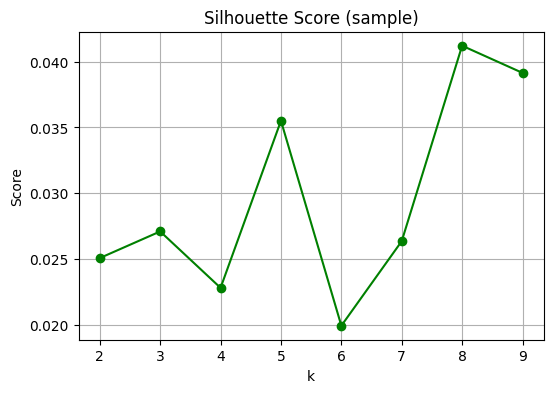

In [ ]:
from sklearn.metrics import silhouette_score
K = range(2, 10)
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_small)
    silhouette_scores.append(silhouette_score(X_small, labels))

plt.figure(figsize=(6, 4))
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score (sample)')
plt.xlabel('k')
plt.ylabel('Score')
plt.grid(True)
plt.show()


 Davies-Bouldin Index

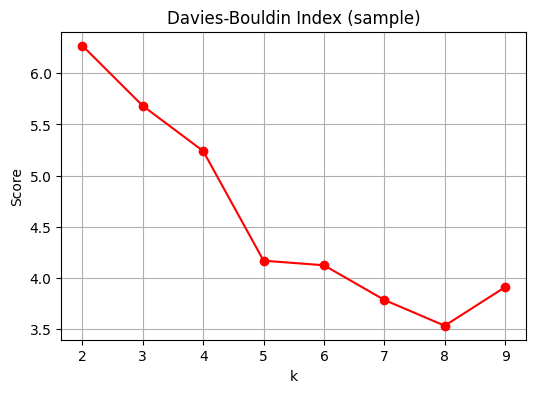

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_small)
    db_scores.append(davies_bouldin_score(X_small, labels))

plt.figure(figsize=(6, 4))
plt.plot(K, db_scores, marker='o', color='red')
plt.title('Davies-Bouldin Index (sample)')
plt.xlabel('k')
plt.ylabel('Score')
plt.grid(True)
plt.show()


Calinski-Harabasz Score

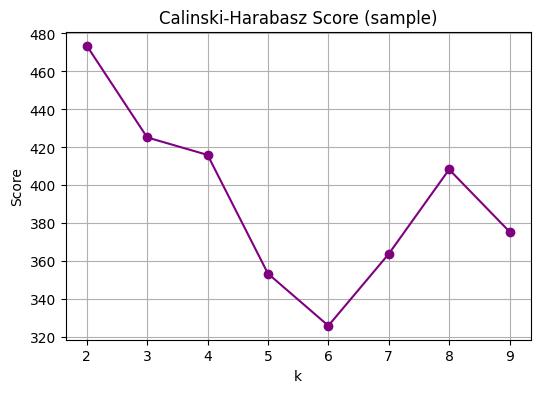

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_small)
    ch_scores.append(calinski_harabasz_score(X_small, labels))

plt.figure(figsize=(6, 4))
plt.plot(K, ch_scores, marker='o', color='purple')
plt.title('Calinski-Harabasz Score (sample)')
plt.xlabel('k')
plt.ylabel('Score')
plt.grid(True)
plt.show()


Все три метрики либо максимальны, либо почти максимальны на k = 8 поэтому рекомендуемое количество кластеров = 8

# KMEANS

In [ ]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=8, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans['cluster_kmeans'] = cluster_labels

print(df_kmeans['cluster_kmeans'].value_counts().sort_index())



cluster_kmeans
0    228788
1     80839
2    258182
3     64745
4    290495
5     28560
6     11744
7     22124
Name: count, dtype: int64


Параметры для DBSCAN

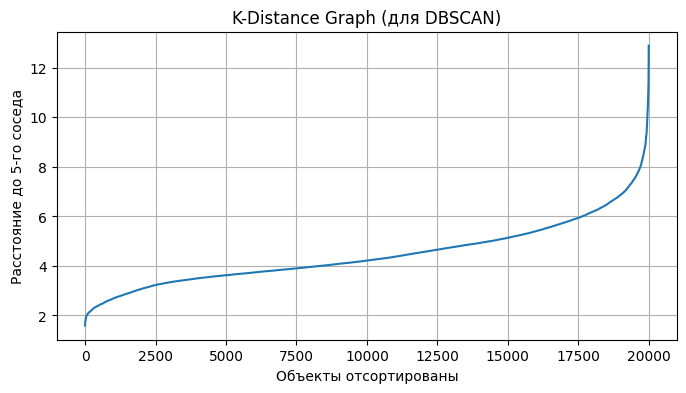

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X_dbscan = X_scaled[:20000]


neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_dbscan)
distances, indices = nbrs.kneighbors(X_dbscan)


distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph (для DBSCAN)')
plt.xlabel('Объекты отсортированы')
plt.ylabel('Расстояние до 5-го соседа')
plt.grid(True)
plt.show()


 Излом происходит примерно на уровне eps ≈ 5

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

#на выборке
dbscan = DBSCAN(eps=8, min_samples=5)
db_labels = dbscan.fit_predict(X_dbscan)

unique_labels, counts = np.unique(db_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Кластер {label}: {count} объектов")


Кластер -1: 157 объектов
Кластер 0: 339 объектов
Кластер 1: 437 объектов
Кластер 2: 281 объектов
Кластер 3: 311 объектов
Кластер 4: 10508 объектов
Кластер 5: 361 объектов
Кластер 6: 387 объектов
Кластер 7: 266 объектов
Кластер 8: 215 объектов
Кластер 9: 337 объектов
Кластер 10: 175 объектов
Кластер 11: 327 объектов
Кластер 12: 244 объектов
Кластер 13: 400 объектов
Кластер 14: 194 объектов
Кластер 15: 430 объектов
Кластер 16: 115 объектов
Кластер 17: 54 объектов
Кластер 18: 251 объектов
Кластер 19: 7 объектов
Кластер 20: 341 объектов
Кластер 21: 147 объектов
Кластер 22: 208 объектов
Кластер 23: 12 объектов
Кластер 24: 151 объектов
Кластер 25: 161 объектов
Кластер 26: 398 объектов
Кластер 27: 283 объектов
Кластер 28: 215 объектов
Кластер 29: 150 объектов
Кластер 30: 208 объектов
Кластер 31: 6 объектов
Кластер 32: 242 объектов
Кластер 33: 218 объектов
Кластер 34: 120 объектов
Кластер 35: 92 объектов
Кластер 36: 50 объектов
Кластер 37: 150 объектов
Кластер 38: 100 объектов
Кластер 39: 9 об

короче не подходит он нам

Параметры для  Agglomerative Clustering

возьмем как и для k-means = 8

In [ ]:
from sklearn.utils import shuffle
X_agglo_sample = shuffle(X_scaled, random_state=42)[:20000]


In [ ]:
from sklearn.utils import shuffle

X_agglo_sample = shuffle(X_scaled, random_state=42)[:20000]
df_agglo = shuffle(df, random_state=42).reset_index(drop=True)[:20000]

from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(n_clusters=8, linkage='ward')
agglo_labels = agglo.fit_predict(X_agglo_sample)

df_agglo['cluster_agglo'] = agglo_labels


 дендрограмма

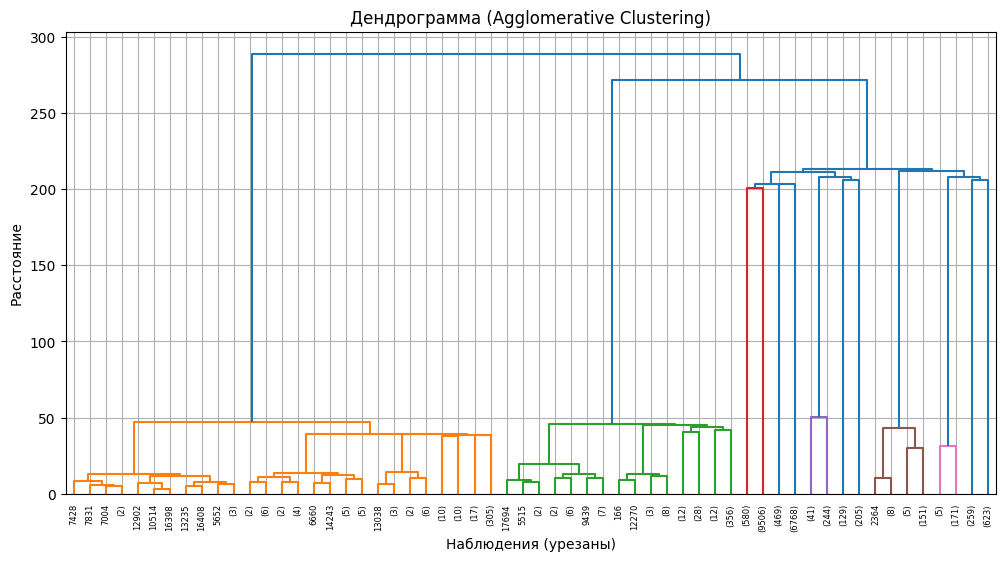

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt


linked = linkage(X_agglo_sample, method='ward')


plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Дендрограмма (Agglomerative Clustering)')
plt.xlabel('Наблюдения (урезаны)')
plt.ylabel('Расстояние')
plt.grid(True)
plt.show()


In [ ]:
cols_numeric = ['Age', 'Income', 'Lifetime', 'trans_6_month', 'trans_12_month', 'amont_trans', 'amont_day_from']

kmeans_stats = df_kmeans.groupby('cluster_kmeans')[cols_numeric].agg(['mean', 'median'])
agglo_stats = df_agglo.groupby('cluster_agglo')[cols_numeric].agg(['mean', 'median'])


In [ ]:
categorical_cols = ['Gender', 'Ind_salary', 'Ind_deposit']

# KMeans
for col in categorical_cols:
    print(f"\n📊 {col} по кластерам (KMeans):")
    display(df_kmeans.groupby('cluster_kmeans')[col].value_counts(normalize=True).unstack().round(2))

# Agglo
for col in categorical_cols:
    print(f"\n📊 {col} по кластерам (Agglomerative):")
    display(df_agglo.groupby('cluster_agglo')[col].value_counts(normalize=True).unstack().round(2))



📊 Gender по кластерам (KMeans):


Gender,F,M,U
cluster_kmeans,,,
0,0.58,0.25,0.17
1,0.55,0.26,0.19
2,0.52,0.27,0.21
3,0.55,0.26,0.19
4,0.54,0.26,0.19
5,0.53,0.28,0.19
6,0.57,0.24,0.19
7,0.54,0.29,0.17



📊 Ind_salary по кластерам (KMeans):


Ind_salary,No,Yes
cluster_kmeans,,
0,1.00,NaN
1,1.00,0.00
2,1.00,NaN
3,NaN,1.00
4,1.00,NaN
5,0.93,0.07
6,0.93,0.07
7,0.93,0.07



📊 Ind_deposit по кластерам (KMeans):


...

Gender,F,M,U
cluster_agglo,,,
0,0.59,0.22,0.19
1,0.58,0.26,0.16
2,0.54,0.27,0.19
3,0.52,0.27,0.22
4,0.51,0.28,0.21
5,0.47,0.32,0.21
6,0.62,0.24,0.15
7,0.55,0.24,0.21



📊 Ind_salary по кластерам (Agglomerative):


Ind_salary,No,Yes
cluster_agglo,,
0,0.93,0.07
1,0.93,0.07
2,0.93,0.07
3,0.93,0.07
4,0.93,0.07
5,0.94,0.06
6,0.93,0.07
7,0.94,0.06



📊 Ind_deposit по кластерам (Agglomerative):


Ind_deposit,No,Yes
cluster_agglo,,
0,0.18,0.82
1,0.21,0.79
2,0.19,0.81
3,0.19,0.81
4,0.15,0.85
5,0.17,0.83
6,0.18,0.82
7,0.15,0.85


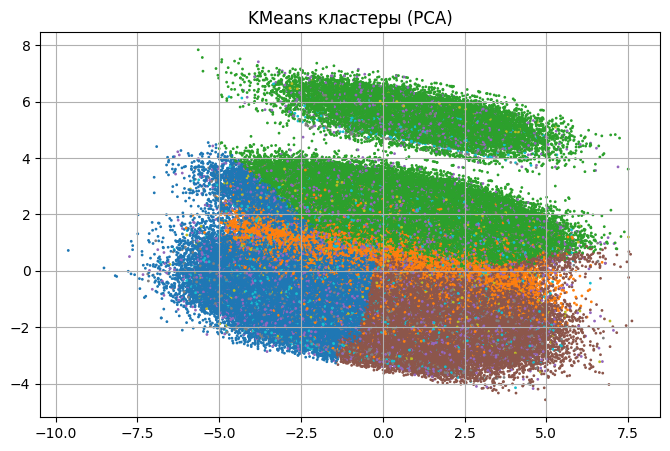

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca_kmeans[:, 0], X_pca_kmeans[:, 1], c=df_kmeans['cluster_kmeans'], cmap='tab10', s=1)
plt.title('KMeans кластеры (PCA)')
plt.grid(True)
plt.show()


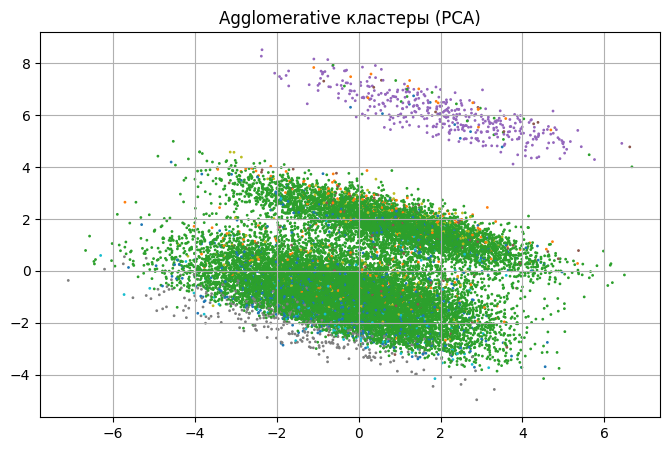

In [ ]:
pca_agglo = PCA(n_components=2)
X_pca_agglo = pca_agglo.fit_transform(X_agglo_sample)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca_agglo[:, 0], X_pca_agglo[:, 1], c=df_agglo['cluster_agglo'], cmap='tab10', s=1)
plt.title('Agglomerative кластеры (PCA)')
plt.grid(True)
plt.show()


In [ ]:

kmeans_numeric_summary = df_kmeans.groupby('cluster_kmeans')[cols_numeric].mean().round()
def cat_summary(df, cluster_col, cat_cols):
    result = []
    for col in cat_cols:
        temp = df.groupby(cluster_col)[col].value_counts(normalize=True).unstack().round(2)
        temp.columns = [f"{col}_{c}" for c in temp.columns]
        result.append(temp)
    return pd.concat(result, axis=1)

kmeans_cat_summary = cat_summary(df_kmeans, 'cluster_kmeans', categorical_cols)


kmeans_final_summary = pd.concat([kmeans_numeric_summary, kmeans_cat_summary], axis=1)


In [ ]:
agglo_numeric_summary = df_agglo.groupby('cluster_agglo')[cols_numeric].mean().round(1)
agglo_cat_summary = cat_summary(df_agglo, 'cluster_agglo', categorical_cols)

agglo_final_summary = pd.concat([agglo_numeric_summary, agglo_cat_summary], axis=1)


In [ ]:
from IPython.display import display

print("📊 KMeans сегменты")
display(kmeans_final_summary)

print("📊 Agglomerative сегменты")
display(agglo_final_summary)


📊 KMeans сегменты


,Age,Income,Lifetime,trans_6_month,trans_12_month,amont_trans,amont_day_from,Gender_F,Gender_M,Gender_U,Ind_salary_No,Ind_salary_Yes,Ind_deposit_No,Ind_deposit_Yes
cluster_kmeans,,,,,,,,,,,,,,
0,46.4,50.4,6.0,1989.2,4109.8,7.2,24.1,0.58,0.25,0.17,1.00,NaN,0.19,0.81
1,52.1,50.4,6.4,2051.1,4191.7,7.2,19.7,0.55,0.26,0.19,1.00,0.00,0.19,0.81
2,68.7,50.3,7.8,2052.9,4193.8,7.2,18.9,0.52,0.27,0.21,1.00,NaN,0.19,0.81
3,53.9,50.4,6.6,2050.1,4190.9,7.3,19.7,0.55,0.26,0.19,NaN,1.00,0.19,0.81
4,46.6,50.4,6.0,2094.8,4249.0,7.2,17.0,0.54,0.26,0.19,1.00,NaN,0.19,0.81
5,52.5,50.4,6.7,2050.4,4190.2,7.2,19.9,0.53,0.28,0.19,0.93,0.07,0.19,0.81
6,55.1,50.5,7.1,2050.2,4189.2,7.2,19.7,0.57,0.24,0.19,0.93,0.07,0.20,0.80
7,52.8,50.4,6.6,2049.3,4189.8,7.2,19.6,0.54,0.29,0.17,0.93,0.07,0.19,0.81


📊 Agglomerative сегменты


,Age,Income,Lifetime,trans_6_month,trans_12_month,amont_trans,amont_day_from,Gender_F,Gender_M,Gender_U,Ind_salary_No,Ind_salary_Yes,Ind_deposit_No,Ind_deposit_Yes
cluster_agglo,,,,,,,,,,,,,,
0,49.9,50.7,6.5,2051.2,4190.0,7.4,19.9,0.59,0.22,0.19,0.93,0.07,0.18,0.82
1,59.7,50.6,7.2,2047.6,4182.9,7.4,19.7,0.58,0.26,0.16,0.93,0.07,0.21,0.79
2,53.5,50.4,6.5,2050.7,4191.9,7.2,19.7,0.54,0.27,0.19,0.93,0.07,0.19,0.81
3,67.0,50.3,7.4,2044.1,4181.9,7.4,19.1,0.52,0.27,0.22,0.93,0.07,0.19,0.81
4,59.1,50.2,5.6,2050.2,4191.3,7.3,19.2,0.51,0.28,0.21,0.93,0.07,0.15,0.85
5,52.0,50.2,6.5,2044.0,4176.2,7.0,19.2,0.47,0.32,0.21,0.94,0.06,0.17,0.83
6,59.9,50.0,6.5,2049.3,4190.5,6.9,19.7,0.62,0.24,0.15,0.93,0.07,0.18,0.82
7,45.7,49.9,6.3,2061.0,4193.5,7.2,19.6,0.55,0.24,0.21,0.94,0.06,0.15,0.85


 Кластер 2 — Пожилые, надёжные

 📈 Age = 68.7

⌛ Lifetime = 7.8

💵 Доход = стандартный

💳 Используют банковские сервисы умеренно


Клиенты старшего возраста, давно с банком. Скорее всего, пенсионеры. Можно предлагать депозиты, страхование, сопровождение.

Кластер 0 — Молодые, но неактивные

👶 Age = 46.4

💸 Доход норм

📉 Самый низкий объём транзакций (1989)

⏳ Lifetime = 6.0 (новее остальных)

Молодые клиенты, недавно присоединились и пока не особо вовлечены.
Цель — увеличить вовлечённость через бонусы, welcome-акции, push-напоминания.